# Question 1 — Analyse univariée des notes d'évaluation

**Contexte proviseur :** comprendre la répartition des résultats, repérer les élèves atypiques et préparer une visualisation simple pour le conseil pédagogique.

**Variables retenues :**
- **Notes (X)** : résultat à l'évaluation interne de mathématiques (/20)
- **Assiduité (Y)** : taux de présence aux cours de maths (%)

Code réutilisable : `src/models/analyse_univariee.py`.


In [1]:
import sys
from pathlib import Path

# Racine du projet (parent si le notebook est dans notebooks/)
RACINE = Path.cwd().resolve()
if RACINE.name == "notebooks":
    RACINE = RACINE.parent
sys.path.insert(0, str(RACINE))

import matplotlib.pyplot as plt
import pandas as pd

from src.data.chargement import charger_donnees_brutes, chemin_figures
from src.models.analyse_univariee import (
    calculer_statistiques_descriptives,
    identifier_outliers,
    tracer_boxplot,
    tracer_histogramme,
)

df = charger_donnees_brutes()
notes = df["Notes"]
print(f"Nombre d'élèves : {len(df)}")
df.head()


Nombre d'élèves : 1000


,Notes,Assiduité,target
0,14.5,69.0,1
1,3.7,16.0,0
2,9.8,48.0,0
3,7.0,38.0,0
4,3.3,21.0,0


In [2]:
stats = calculer_statistiques_descriptives(notes)

print("=== Statistiques descriptives — Notes (/20) ===")
print(f"Moyenne     : {stats['mean']:.2f}")
print(f"Écart-type  : {stats['std']:.2f}")
print(f"Q1 / Médiane / Q3 : {stats['25%']:.1f} / {stats['50%']:.1f} / {stats['75%']:.1f}")
print(f"Min / Max   : {stats['min']:.1f} / {stats['max']:.1f}")
print(f"Outliers Tukey : {int(stats['nb_outliers_bas'])} bas, {int(stats['nb_outliers_haut'])} hauts")

stats


=== Statistiques descriptives — Notes (/20) ===
Moyenne     : 9.90
Écart-type  : 5.87
Q1 / Médiane / Q3 : 4.8 / 9.8 / 15.1
Min / Max   : 0.0 / 20.0
Outliers Tukey : 0 bas, 0 hauts


count                1000.000000
mean                    9.903000
std                     5.873167
min                     0.000000
25%                     4.800000
50%                     9.750000
75%                    15.100000
max                    20.000000
IQR                    10.300000
borne_basse_tukey     -10.650000
borne_haute_tukey      30.550000
nb_outliers_bas         0.000000
nb_outliers_haut        0.000000
Name: Notes, dtype: float64

In [3]:
outliers = identifier_outliers(df)
print(f"{len(outliers)} élève(s) atypique(s)")
outliers[["Notes", "Assiduité", "target"]].head(15)


0 élève(s) atypique(s)


,Notes,Assiduité,target


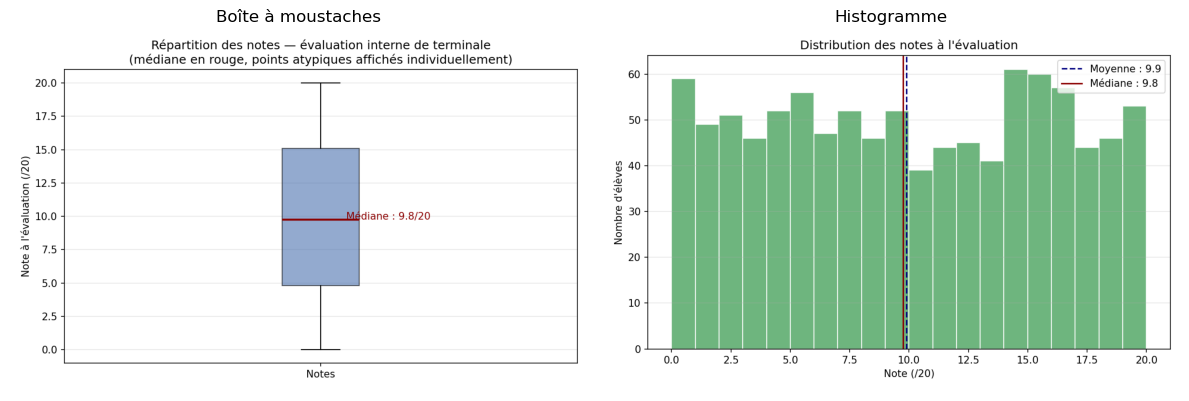

In [4]:
dossier = chemin_figures()
tracer_boxplot(notes, dossier / "boxplot_notes_evaluation.png")
tracer_histogramme(notes, dossier / "histogramme_notes_evaluation.png")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(plt.imread(dossier / "boxplot_notes_evaluation.png"))
axes[0].axis("off")
axes[0].set_title("Boîte à moustaches")
axes[1].imshow(plt.imread(dossier / "histogramme_notes_evaluation.png"))
axes[1].axis("off")
axes[1].set_title("Histogramme")
plt.tight_layout()
plt.show()


## Synthèse pour le conseil pédagogique

- La **boîte à moustaches** montre médiane, dispersion et élèves atypiques en un graphique.
- Les notes extrêmes (haut ou bas) appellent un accompagnement individualisé, pas une décision automatique.
